In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

I0000 00:00:1773814046.336817    3957 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773814046.374256    3957 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773814047.284382    3957 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

/home/dhruvgoel/Documents/ml/mlenv/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

/home/dhruvgoel/Documents/ml/mlenv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1773814083.113373    3957 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1773814083.121337    3957 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1773814083.249958    3957 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5802 MB memory:  -> device: 0, name: NVI

In [5]:
model.compile(optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])

In [6]:
history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_test, y_test))

Epoch 1/10


I0000 00:00:1773814118.933552    4090 service.cc:153] XLA service 0x7fd54c006380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773814118.933571    4090 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1773814118.958621    4090 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773814119.118836    4090 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1773814119.125262    4090 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1926__.31
I0000 00:00:1773814119.366302    4185 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 16 bytes spill stores, 16 bytes spill loads



  32/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1097 - loss: 2.2963

I0000 00:00:1773814123.399076    4090 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1560/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3725 - loss: 1.7028

I0000 00:00:1773814129.934148    4087 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1926__.31
I0000 00:00:1773814130.131732    4434 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 16 bytes spill stores, 16 bytes spill loads



1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3726 - loss: 1.7023

I0000 00:00:1773814135.034410    4778 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 8 bytes spill stores, 8 bytes spill loads



1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.4717 - loss: 1.4567 - val_accuracy: 0.5599 - val_loss: 1.2283
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6201 - loss: 1.0796 - val_accuracy: 0.6231 - val_loss: 1.0886
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6735 - loss: 0.9304 - val_accuracy: 0.6785 - val_loss: 0.9256
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7138 - loss: 0.8282 - val_accuracy: 0.6898 - val_loss: 0.8826
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7358 - loss: 0.7514 - val_accuracy: 0.7025 - val_loss: 0.8674
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7643 - loss: 0.6753 - val_accuracy: 0.7004 - val_loss: 0.8777
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7830 - loss: 0.6136 - val_accuracy: 0.7171 - val_loss: 0.8574
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8064 - loss: 0.5447 - val_accura

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7069 - loss: 1.0024
Test Accuracy: 0.7069000005722046


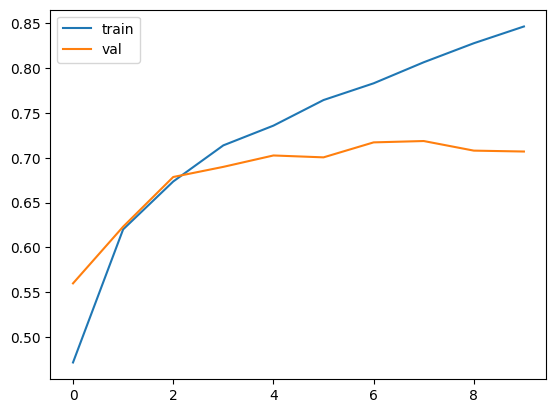

In [8]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

In [9]:
class_names = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']

In [10]:
import numpy as np
pred = model.predict(x_test[:1])
print("Predicted:", class_names[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
Predicted: cat
